── Jacobians ──────────────────────
J_front:


Matrix([
[1, 0,  l*(sin(a1(t) + theta(t)) + sin(theta(t)))/2,  l*sin(a1(t) + theta(t))/2, 0],
[0, 1, -l*(cos(a1(t) + theta(t)) + cos(theta(t)))/2, -l*cos(a1(t) + theta(t))/2, 0]])

J_tail:


Matrix([
[1, 0, -l*(sin(a2(t) + theta(t)) + sin(theta(t)))/2, 0, -l*sin(a2(t) + theta(t))/2],
[0, 1,  l*(cos(a2(t) + theta(t)) + cos(theta(t)))/2, 0,  l*cos(a2(t) + theta(t))/2]])


── Mass matrix M(q) ────────────────


...


── Coriolis vector h(q,q_dot) ──────


Matrix([
[l*m*(cos(a1(t) + theta(t))*Derivative(a1(t), t)**2 + 2*cos(a1(t) + theta(t))*Derivative(a1(t), t)*Derivative(theta(t), t) + cos(a1(t) + theta(t))*Derivative(theta(t), t)**2 - cos(a2(t) + theta(t))*Derivative(a2(t), t)**2 - 2*cos(a2(t) + theta(t))*Derivative(a2(t), t)*Derivative(theta(t), t) - cos(a2(t) + theta(t))*Derivative(theta(t), t)**2)/2],
[l*m*(sin(a1(t) + theta(t))*Derivative(a1(t), t)**2 + 2*sin(a1(t) + theta(t))*Derivative(a1(t), t)*Derivative(theta(t), t) + sin(a1(t) + theta(t))*Derivative(theta(t), t)**2 - sin(a2(t) + theta(t))*Derivative(a2(t), t)**2 - 2*sin(a2(t) + theta(t))*Derivative(a2(t), t)*Derivative(theta(t), t) - sin(a2(t) + theta(t))*Derivative(theta(t), t)**2)/2],
[                                                                                                                                              -l**2*m*(sin(a1(t))*Derivative(a1(t), t)**2 + 2*sin(a1(t))*Derivative(a1(t), t)*Derivative(theta(t), t) + sin(a2(t))*Derivative(a2(t), t)**2 + 2*sin(a


── Q_flow ──────────────────────────


Matrix([
[                                                                                                                                                                                                                                                                                                                                       c*(6*U_flow - l*sin(a1(t) + theta(t))*Derivative(a1(t), t) - l*sin(a1(t) + theta(t))*Derivative(theta(t), t) + l*sin(a2(t) + theta(t))*Derivative(a2(t), t) + l*sin(a2(t) + theta(t))*Derivative(theta(t), t) - 6*Derivative(x(t), t))/2],
[                                                                                                                                                                                                                                                                                                                                     c*(6*U_flow_y + l*cos(a1(t) + theta(t))*Derivative(a1(t), t) + l*cos(a1(t) + theta(t))*Derivative(thet


Running baseline simulation (Ux=0, Uy=0)…
  Final:  x=0.0165  y=-0.0740  θ=0.1445
Sweeping gait amplitudes…
  Best amplitude: 1.5157 rad
  Max distance:   0.1098 m
Sweeping Ux (Uy=0)…
Sweeping Uy (Ux=0)…
Running diagonal flow simulation (Ux=0.5, Uy=0.5)…


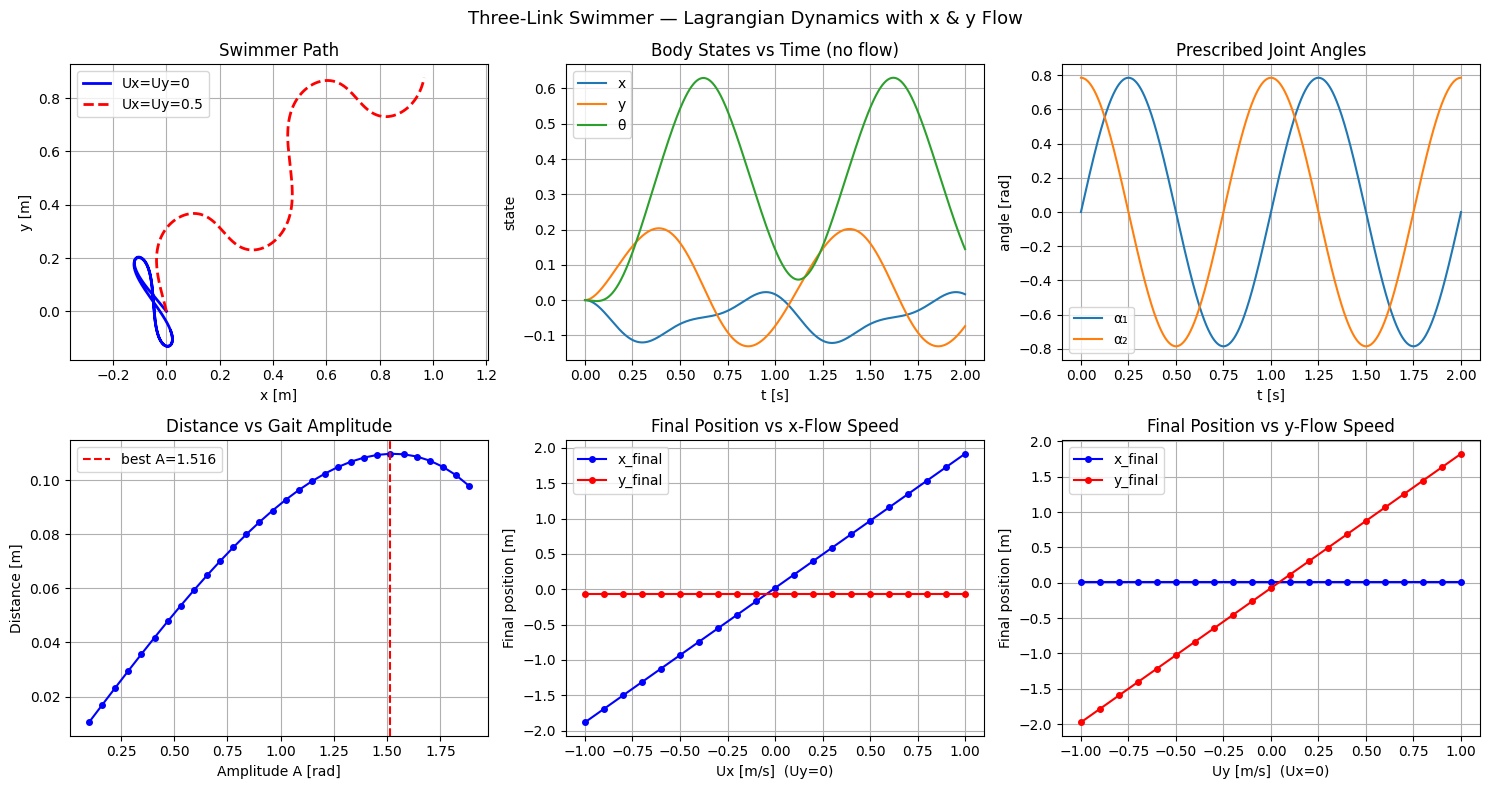

Done. Plot saved to swimmer_flow_dynamics.png


In [1]:
"""
Three-Link Swimmer in a Flow Field — Dynamic Model
====================================================
Implements the Lagrangian dynamics for a three-link planar swimmer
in an external flow field, following the model in the course notes.

Generalized coordinates:  q = [x, y, theta, alpha1, alpha2]^T
  (x, y)   : position of base link center in world frame
  theta    : orientation of base link
  alpha1   : joint angle (front link, at -x end of base)
  alpha2   : joint angle (tail  link, at +x end of base)

Swimmer layout:  [Front] --a1-- [Base] --a2-- [Tail]

Equations of motion (Eqs. 15-16, wtv.pdf):
  M(q) @ q_ddot + h(q, q_dot) = Q_act + Q_flow
  Q_flow = sum_i  J_i^T @ F_i          (Eq. 11)
  F_i    = -c * v_rel,i                 (Eq. 7, linear drag)
  v_rel,i = J_i @ q_dot - vf(r_i)      (Eq. 6)

For a prescribed gait the joint DOFs are forced, and the passive
body DOFs (x, y, theta) are found by solving the first 3 rows:
  M11 @ [x_ddot; y_ddot; theta_ddot]
      = Q_flow[0:3] - h[0:3] - M12 @ [alpha1_ddot; alpha2_ddot]
"""

from sympy import *
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────────────────
# 1.  SYMBOLIC VARIABLES
# ─────────────────────────────────────────────────────────────────────────────
t = symbols("t", real=True)

# Physical parameters (all positive)
l, m, I_link, c = symbols("l m I c", positive=True, real=True)
U_flow   = symbols("U_flow",   real=True)   # background flow speed (x-direction)
U_flow_y = symbols("U_flow_y", real=True)   # background flow speed (y-direction)

# Generalised coordinates as time-functions
x     = Function("x")(t)
y     = Function("y")(t)
theta = Function("theta")(t)
a1    = Function("a1")(t)
a2    = Function("a2")(t)

q    = [x, y, theta, a1, a2]             # position-level DOFs
q_dt = [diff(v, t) for v in q]           # velocity-level DOFs
n    = 5

# ─────────────────────────────────────────────────────────────────────────────
# 2.  SE(3) HELPERS  (same style as sample code)
# ─────────────────────────────────────────────────────────────────────────────
def R_z(ang):
    return Matrix([[cos(ang), -sin(ang), 0],
                   [sin(ang),  cos(ang), 0],
                   [0,         0,        1]])

def make_T(R, p):
    """4x4 homogeneous transform: rotation R (3x3), translation p (3x1 column vector).
    Constructed element-wise to avoid SymPy slice-assignment version issues."""
    return Matrix([
        [R[0, 0], R[0, 1], R[0, 2], p[0, 0]],
        [R[1, 0], R[1, 1], R[1, 2], p[1, 0]],
        [R[2, 0], R[2, 1], R[2, 2], p[2, 0]],
        [0,       0,       0,       1       ]
    ])

# ─────────────────────────────────────────────────────────────────────────────
# 3.  LINK TRANSFORMS  — center of each link in world frame
#
#     Link orientations (Sec. 1.1, wtv.pdf):
#       theta_base  = theta
#       theta_front = theta + alpha1
#       theta_tail  = theta + alpha2
# ─────────────────────────────────────────────────────────────────────────────
T_base  = make_T(R_z(theta), Matrix([[x], [y], [0]]))

# Front link: move to left end of base (-l/2), rotate a1, move to link center
T_front = (T_base
           @ make_T(Matrix.eye(3), Matrix([[-l/2], [0], [0]]))
           @ make_T(R_z(a1),       Matrix([[0],    [0], [0]]))
           @ make_T(Matrix.eye(3), Matrix([[-l/2], [0], [0]])))

# Tail link: move to right end of base (+l/2), rotate a2, move to link center
T_tail  = (T_base
           @ make_T(Matrix.eye(3), Matrix([[l/2], [0], [0]]))
           @ make_T(R_z(a2),       Matrix([[0],   [0], [0]]))
           @ make_T(Matrix.eye(3), Matrix([[l/2], [0], [0]])))

# ─────────────────────────────────────────────────────────────────────────────
# 4.  LINK CENTER POSITIONS  r_i(q)   and  TRANSLATIONAL JACOBIANS  J_i
#     v_i = J_i @ q_dot   is the world-frame velocity of link i's center
#     (Eq. 3 and Eq. 5, wtv.pdf)
# ─────────────────────────────────────────────────────────────────────────────
r_base  = Matrix([T_base[0, 3],  T_base[1, 3]])            # = [x, y]
r_front = simplify(Matrix([T_front[0, 3], T_front[1, 3]]))
r_tail  = simplify(Matrix([T_tail[0,  3], T_tail[1,  3]]))

J_base  = r_base.jacobian(q)                    # constant: [[1,0,0,0,0],[0,1,0,0,0]]
J_front = simplify(r_front.jacobian(q))         # 2×5
J_tail  = simplify(r_tail.jacobian(q))          # 2×5

print("── Jacobians ──────────────────────")
print("J_front:"); display(J_front)
print("J_tail:");  display(J_tail)

# ─────────────────────────────────────────────────────────────────────────────
# 5.  KINETIC ENERGY  and  MASS MATRIX  M(q)
#
#     T = Σ_i [ ½ m_i  vᵢᵀ vᵢ  +  ½ Iᵢ ωᵢ² ]     (Eq. 12, wtv.pdf)
#     ω_base  = θ̇,   ω_front = θ̇+α̇₁,   ω_tail = θ̇+α̇₂
# ─────────────────────────────────────────────────────────────────────────────
qd = Matrix(q_dt)

def link_KE(J_v, omega_sym):
    """Kinetic energy contribution of one link."""
    v = J_v @ qd
    return Rational(1, 2) * m * (v.T @ v)[0, 0] + Rational(1, 2) * I_link * omega_sym**2

T_kin = expand(
    link_KE(J_base,  q_dt[2])              +   # base  (ω = θ̇)
    link_KE(J_front, q_dt[2] + q_dt[3])   +   # front (ω = θ̇+α̇₁)
    link_KE(J_tail,  q_dt[2] + q_dt[4])       # tail  (ω = θ̇+α̇₂)
)

# M_ij = ∂²T / (∂q̇_i ∂q̇_j)
M_mat = simplify(Matrix([
    [diff(diff(T_kin, q_dt[i]), q_dt[j]) for j in range(n)]
    for i in range(n)
]))
print("\n── Mass matrix M(q) ────────────────"); display(M_mat)

# ─────────────────────────────────────────────────────────────────────────────
# 6.  CORIOLIS / CENTRIFUGAL VECTOR   h(q, q_dot) = C(q,q_dot) @ q_dot
#
#     Computed directly from the Euler–Lagrange expression without building
#     the full C matrix, by applying the chain rule and zeroing q̈:
#       h_i = [ d/dt(∂T/∂q̇_i) ]_{q̈=0}  −  ∂T/∂q_i
#
#     This avoids the O(n³) Christoffel-symbol triple loop.
# ─────────────────────────────────────────────────────────────────────────────
# Dummy symbols for q̈ so we can substitute them to zero cleanly
q_ddt_syms = symbols("xdd ydd thdd a1dd a2dd")

h_vec = Matrix.zeros(n, 1)
for i in range(n):
    dT_i   = diff(T_kin, q_dt[i])
    # chain rule:  d/dt(dT/dqdot_i) = Σ_j [ ∂/∂q_j * q̇_j  +  ∂/∂q̇_j * q̈_j ]
    ddt_i  = sum(
        diff(dT_i, q[j])    * q_dt[j] +
        diff(dT_i, q_dt[j]) * q_ddt_syms[j]
        for j in range(n)
    )
    # zero out q̈ to isolate the h part (M @ q̈ vanishes)
    h_vec[i] = simplify(
        ddt_i.subs(dict(zip(q_ddt_syms, [0]*n))) - diff(T_kin, q[i])
    )
print("\n── Coriolis vector h(q,q_dot) ──────"); display(h_vec)

# ─────────────────────────────────────────────────────────────────────────────
# 7.  FLOW FIELD  vf(x,y)  and  GENERALISED HYDRODYNAMIC FORCES  Q_flow
#
#     vf(x,y) = [u(x,y), v(x,y)]           (Eq. 2, wtv.pdf)
#     v_rel,i = J_i @ q̇ − vf(r_i)          (Eq. 6)
#     F_i     = −c · v_rel,i               (Eq. 7, linear drag)
#     Q_i     = J_iᵀ @ F_i                 (Eq. 9)
#     Q_flow  = Σ_i Q_i                    (Eq. 11)
#
#     ── Change flow_field() to use any spatially varying field ──
# ─────────────────────────────────────────────────────────────────────────────
def flow_field(px, py):
    """
    Return the 2-vector [u, v] at world position (px, py).
    U_flow   : uniform flow in the +x direction
    U_flow_y : uniform flow in the +y direction
    Examples of spatially varying fields:
      Shear:   Matrix([U_flow * py,  U_flow_y * px])
      Vortex:  Matrix([-U_flow * py, U_flow * px]) / (px**2 + py**2 + 1)
    """
    return Matrix([U_flow, U_flow_y])

def generalized_drag_force(J_v, r_i):
    """Generalised force contribution from drag on one link."""
    vf_i  = flow_field(r_i[0], r_i[1])   # flow at link center   (Eq. 4)
    v_i   = J_v @ qd                      # link velocity          (Eq. 5)
    vrel  = v_i - vf_i                    # relative velocity      (Eq. 6)
    F_i   = -c * vrel                     # linear drag force      (Eq. 7)
    return J_v.T @ F_i                    # generalised force      (Eq. 9)

Q_flow = simplify(
    generalized_drag_force(J_base,  r_base)  +
    generalized_drag_force(J_front, r_front) +
    generalized_drag_force(J_tail,  r_tail)
)
print("\n── Q_flow ──────────────────────────"); display(Q_flow)

# ─────────────────────────────────────────────────────────────────────────────
# 8.  LAMBDIFY  —  convert SymPy expressions to fast NumPy functions
# ─────────────────────────────────────────────────────────────────────────────
params_sym = [l, m, I_link, c, U_flow, U_flow_y]

M_fn  = lambdify([q, params_sym],        M_mat,  "numpy")
h_fn  = lambdify([q, q_dt, params_sym],  h_vec,  "numpy")
Qf_fn = lambdify([q, q_dt, params_sym],  Q_flow, "numpy")

# ─────────────────────────────────────────────────────────────────────────────
# 9.  PHYSICAL PARAMETERS & PRESCRIBED GAIT  (Sec. 1.6, wtv.pdf)
#
#     α_i(t) = A_i · sin(ω t + φ_i)
# ─────────────────────────────────────────────────────────────────────────────
l_val = 1.0                          # link length [m]
m_val = 0.1                          # link mass   [kg]
I_val = m_val * l_val**2 / 12.0     # rod moment of inertia [kg m²]
c_val = 1.0                          # drag coefficient

def make_params(U=0.0, Uy=0.0):
    return [l_val, m_val, I_val, c_val, U, Uy]

A1_g  = np.pi / 4                    # front-joint amplitude  [rad]
A2_g  = np.pi / 4                    # tail-joint  amplitude  [rad]
w_g   = 2.0 * np.pi                  # gait frequency         [rad/s]
phi_g = np.pi / 2                    # phase offset           [rad]

def gait(tv):
    """Return (α₁, α₂, α̇₁, α̇₂, α̈₁, α̈₂) at time tv."""
    a1v  =  A1_g * np.sin(w_g * tv)
    a2v  =  A2_g * np.sin(w_g * tv + phi_g)
    a1d  =  A1_g * w_g  * np.cos(w_g * tv)
    a2d  =  A2_g * w_g  * np.cos(w_g * tv + phi_g)
    a1dd = -A1_g * w_g**2 * np.sin(w_g * tv)
    a2dd = -A2_g * w_g**2 * np.sin(w_g * tv + phi_g)
    return a1v, a2v, a1d, a2d, a1dd, a2dd

# ─────────────────────────────────────────────────────────────────────────────
# 10.  ODE FUNCTION
#
#      State vector: s = [x, y, θ, ẋ, ẏ, θ̇]   (6-dimensional)
#      Joint angles α₁, α₂ are prescribed by gait() — not in the state.
#
#      Passive-DOF rows of EOM (no actuation on x, y, θ):
#        M11 @ [ẍ; ÿ; θ̈] = Q_flow[0:3] − h[0:3] − M12 @ [α̈₁; α̈₂]
# ─────────────────────────────────────────────────────────────────────────────
def dynamics(tv, state, p_vals):
    xv, yv, thv, xd, yd, thd = state
    a1v, a2v, a1d, a2d, a1dd, a2dd = gait(tv)

    qc  = [xv,  yv,  thv, a1v, a2v]
    qdc = [xd,  yd,  thd, a1d, a2d]

    M_  = np.array(M_fn(qc, p_vals),           dtype=float)
    h_  = np.array(h_fn(qc, qdc, p_vals),      dtype=float).flatten()
    Qf_ = np.array(Qf_fn(qc, qdc, p_vals),     dtype=float).flatten()

    alpha_ddot = np.array([a1dd, a2dd])
    rhs        = Qf_[0:3] - h_[0:3] - M_[0:3, 3:5] @ alpha_ddot
    q_ddot_pas = np.linalg.solve(M_[0:3, 0:3], rhs)

    return [xd, yd, thd, *q_ddot_pas]

# ─────────────────────────────────────────────────────────────────────────────
# 11.  SIMULATE — single trajectory  (Ux=0, Uy=0  →  no flow baseline)
# ─────────────────────────────────────────────────────────────────────────────
t_span = [0.0, 2.0]
t_eval = np.linspace(0.0, 2.0, 2000)
s0     = [0.0] * 6                  # start at rest at origin

print("\nRunning baseline simulation (Ux=0, Uy=0)…")
sol = solve_ivp(
    lambda tv, s: dynamics(tv, s, make_params(U=0.0, Uy=0.0)),
    t_span, s0, t_eval=t_eval, rtol=1e-7, atol=1e-7
)
print(f"  Final:  x={sol.y[0,-1]:.4f}  y={sol.y[1,-1]:.4f}  θ={sol.y[2,-1]:.4f}")

# ─────────────────────────────────────────────────────────────────────────────
# 12.  SWEEP — gait amplitude
# ─────────────────────────────────────────────────────────────────────────────
A_values  = np.linspace(0.1, 1.2 * np.pi / 2, 30)
distances = []

print("Sweeping gait amplitudes…")
for A_curr in A_values:
    A1_g = A_curr;  A2_g = A_curr
    sv = solve_ivp(
        lambda tv, s: dynamics(tv, s, make_params(U=0.0, Uy=0.0)),
        t_span, s0, t_eval=t_eval, rtol=1e-6, atol=1e-6
    )
    distances.append(np.sqrt(sv.y[0, -1]**2 + sv.y[1, -1]**2))

A1_g = A2_g = np.pi / 4   # restore defaults

best_idx = np.argmax(distances)
print(f"  Best amplitude: {A_values[best_idx]:.4f} rad")
print(f"  Max distance:   {distances[best_idx]:.4f} m")

# ─────────────────────────────────────────────────────────────────────────────
# 13.  SWEEP — x-flow speed Ux  and  y-flow speed Uy  (independently)
# ─────────────────────────────────────────────────────────────────────────────
U_values = np.linspace(-1.0, 1.0, 21)

# Sweep Ux with Uy=0
x_end_ux, y_end_ux = [], []
print("Sweeping Ux (Uy=0)…")
for U in U_values:
    sv = solve_ivp(
        lambda tv, s: dynamics(tv, s, make_params(U=U, Uy=0.0)),
        t_span, s0, t_eval=t_eval, rtol=1e-6, atol=1e-6
    )
    x_end_ux.append(sv.y[0, -1])
    y_end_ux.append(sv.y[1, -1])

# Sweep Uy with Ux=0
x_end_uy, y_end_uy = [], []
print("Sweeping Uy (Ux=0)…")
for Uy in U_values:
    sv = solve_ivp(
        lambda tv, s: dynamics(tv, s, make_params(U=0.0, Uy=Uy)),
        t_span, s0, t_eval=t_eval, rtol=1e-6, atol=1e-6
    )
    x_end_uy.append(sv.y[0, -1])
    y_end_uy.append(sv.y[1, -1])

# Simulate with both Ux and Uy non-zero for comparison trajectory
print("Running diagonal flow simulation (Ux=0.5, Uy=0.5)…")
sol_diag = solve_ivp(
    lambda tv, s: dynamics(tv, s, make_params(U=0.5, Uy=0.5)),
    t_span, s0, t_eval=t_eval, rtol=1e-7, atol=1e-7
)

# ─────────────────────────────────────────────────────────────────────────────
# 14.  PLOTS
# ─────────────────────────────────────────────────────────────────────────────
t_arr = sol.t
a1arr = A1_g * np.sin(w_g * t_arr)
a2arr = A2_g * np.sin(w_g * t_arr + phi_g)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Three-Link Swimmer — Lagrangian Dynamics with x & y Flow", fontsize=13)

# Trajectory: no flow vs diagonal flow
axes[0, 0].plot(sol.y[0],      sol.y[1],      "b-",  lw=2, label="Ux=Uy=0")
axes[0, 0].plot(sol_diag.y[0], sol_diag.y[1], "r--", lw=2, label="Ux=Uy=0.5")
axes[0, 0].set_xlabel("x [m]"); axes[0, 0].set_ylabel("y [m]")
axes[0, 0].set_title("Swimmer Path")
axes[0, 0].axis("equal"); axes[0, 0].legend(); axes[0, 0].grid(True)

# Body states vs time (baseline)
axes[0, 1].plot(t_arr, sol.y[0], label="x")
axes[0, 1].plot(t_arr, sol.y[1], label="y")
axes[0, 1].plot(t_arr, sol.y[2], label="θ")
axes[0, 1].set_xlabel("t [s]"); axes[0, 1].set_ylabel("state")
axes[0, 1].set_title("Body States vs Time (no flow)"); axes[0, 1].legend(); axes[0, 1].grid(True)

# Prescribed joint angles
axes[0, 2].plot(t_arr, a1arr, label="α₁")
axes[0, 2].plot(t_arr, a2arr, label="α₂")
axes[0, 2].set_xlabel("t [s]"); axes[0, 2].set_ylabel("angle [rad]")
axes[0, 2].set_title("Prescribed Joint Angles"); axes[0, 2].legend(); axes[0, 2].grid(True)

# Distance vs gait amplitude
axes[1, 0].plot(A_values, distances, "b-o", ms=4)
axes[1, 0].axvline(A_values[best_idx], color="r", ls="--",
                   label=f"best A={A_values[best_idx]:.3f}")
axes[1, 0].set_xlabel("Amplitude A [rad]"); axes[1, 0].set_ylabel("Distance [m]")
axes[1, 0].set_title("Distance vs Gait Amplitude"); axes[1, 0].legend(); axes[1, 0].grid(True)

# Final position vs Ux (Uy=0)
axes[1, 1].plot(U_values, x_end_ux, "b-o", ms=4, label="x_final")
axes[1, 1].plot(U_values, y_end_ux, "r-o", ms=4, label="y_final")
axes[1, 1].set_xlabel("Ux [m/s]  (Uy=0)"); axes[1, 1].set_ylabel("Final position [m]")
axes[1, 1].set_title("Final Position vs x-Flow Speed")
axes[1, 1].legend(); axes[1, 1].grid(True)

# Final position vs Uy (Ux=0)
axes[1, 2].plot(U_values, x_end_uy, "b-o", ms=4, label="x_final")
axes[1, 2].plot(U_values, y_end_uy, "r-o", ms=4, label="y_final")
axes[1, 2].set_xlabel("Uy [m/s]  (Ux=0)"); axes[1, 2].set_ylabel("Final position [m]")
axes[1, 2].set_title("Final Position vs y-Flow Speed")
axes[1, 2].legend(); axes[1, 2].grid(True)

plt.tight_layout()
plt.savefig("swimmer_flow_dynamics.png", dpi=100, bbox_inches="tight")
plt.show()
print("Done. Plot saved to swimmer_flow_dynamics.png")